# 01 — Exploration des données RES2-6-9 kVA
Chargement, inspection et visualisation des courbes de charge résidentielles Enedis RES2, clients avec chauffage électrique et puissance souscrite 6-9 kVA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

## 1.1 Chargement

In [2]:
DATA_PATH = '../data/RES2-6-9.csv'

df = pd.read_csv(DATA_PATH, sep=';')

# Le fichier donne une puissance en W au pas de 30 minutes.
# On convertit en kW ; pour obtenir des kWh sur un pas, on multiplie ensuite par 0.5 h.
df['kw'] = df['valeur'] / 1000

# Dates avec fuseaux mixtes (+01:00 hiver / +02:00 été) → UTC puis tz-naive.
df['horodate'] = pd.to_datetime(df['horodate'], utc=True).dt.tz_convert(None)

print(f"Fichier : {DATA_PATH}")
print(f"Shape : {df.shape}")
print(f"Clients : {df['ID'].nunique()}")
print(f"Période : {df['horodate'].min()} → {df['horodate'].max()}")
df.head()


Fichier : ../data/RES2-6-9.csv
Shape : (8736000, 4)
Clients : 500
Période : 2023-10-31 23:00:00 → 2024-10-29 22:30:00


,ID,horodate,valeur,kw
0,476866365062,2023-10-31 23:00:00,1328.1,1.3281
1,476866365062,2023-10-31 23:30:00,240.7,0.2407
2,476866365062,2023-11-01 00:00:00,245.7,0.2457
3,476866365062,2023-11-01 00:30:00,324.5,0.3245
4,476866365062,2023-11-01 01:00:00,238.0,0.2380


## 1.2 Statistiques de base

In [3]:
df.info()
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nStats valeur (kW) :")
df['kw'].describe().round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736000 entries, 0 to 8735999
Data columns (total 4 columns):
 #   Column    Dtype         
---  ------    -----         
 0   ID        int64         
 1   horodate  datetime64[ns]
 2   valeur    float64       
 3   kw        float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 266.6 MB

Valeurs manquantes :
ID          0
horodate    0
valeur      0
kw          0
dtype: int64

Stats valeur (kW) :


count    8736000.000
mean           0.664
std            0.798
min            0.000
25%            0.138
50%            0.325
75%            0.890
max            8.998
Name: kw, dtype: float64

## 1.3 Reshape : matrice clients × timestamps (pivot)

In [4]:
df_pivot = df.pivot_table(index='ID', columns='horodate', values='kw')

print(f"Pivot shape : {df_pivot.shape}")
print(f"  → {df_pivot.shape[0]} clients × {df_pivot.shape[1]} créneaux")
print(f"Valeurs manquantes : {df_pivot.isnull().sum().sum()}")

# Remplissage des éventuels trous par interpolation linéaire
df_pivot = df_pivot.interpolate(axis=1, limit_direction='both')
df_pivot.head(2)

Pivot shape : (500, 17472)
  → 500 clients × 17472 créneaux
Valeurs manquantes : 0


horodate,2023-10-31 23:00:00,2023-10-31 23:30:00,2023-11-01 00:00:00,2023-11-01 00:30:00,2023-11-01 01:00:00,2023-11-01 01:30:00,2023-11-01 02:00:00,2023-11-01 02:30:00,2023-11-01 03:00:00,2023-11-01 03:30:00,...,2024-10-29 18:00:00,2024-10-29 18:30:00,2024-10-29 19:00:00,2024-10-29 19:30:00,2024-10-29 20:00:00,2024-10-29 20:30:00,2024-10-29 21:00:00,2024-10-29 21:30:00,2024-10-29 22:00:00,2024-10-29 22:30:00
ID,,,,,,,,,,,,,,,,,,,,,
1704875583,0.3088,0.3304,0.2990,0.2457,0.2589,0.2323,0.3042,0.3028,0.3711,0.3591,...,1.7976,0.7165,0.5924,0.6490,0.6341,0.4805,0.5188,1.5209,0.8027,0.6644
6674572658,0.1230,0.0933,0.0811,0.1376,0.1495,0.0788,0.0391,0.9093,3.2809,2.0668,...,1.9444,0.8351,0.3331,0.1623,0.1227,0.1855,0.1190,0.0962,0.0501,0.0994


## 1.4 Visualisation de 10 profils annuels

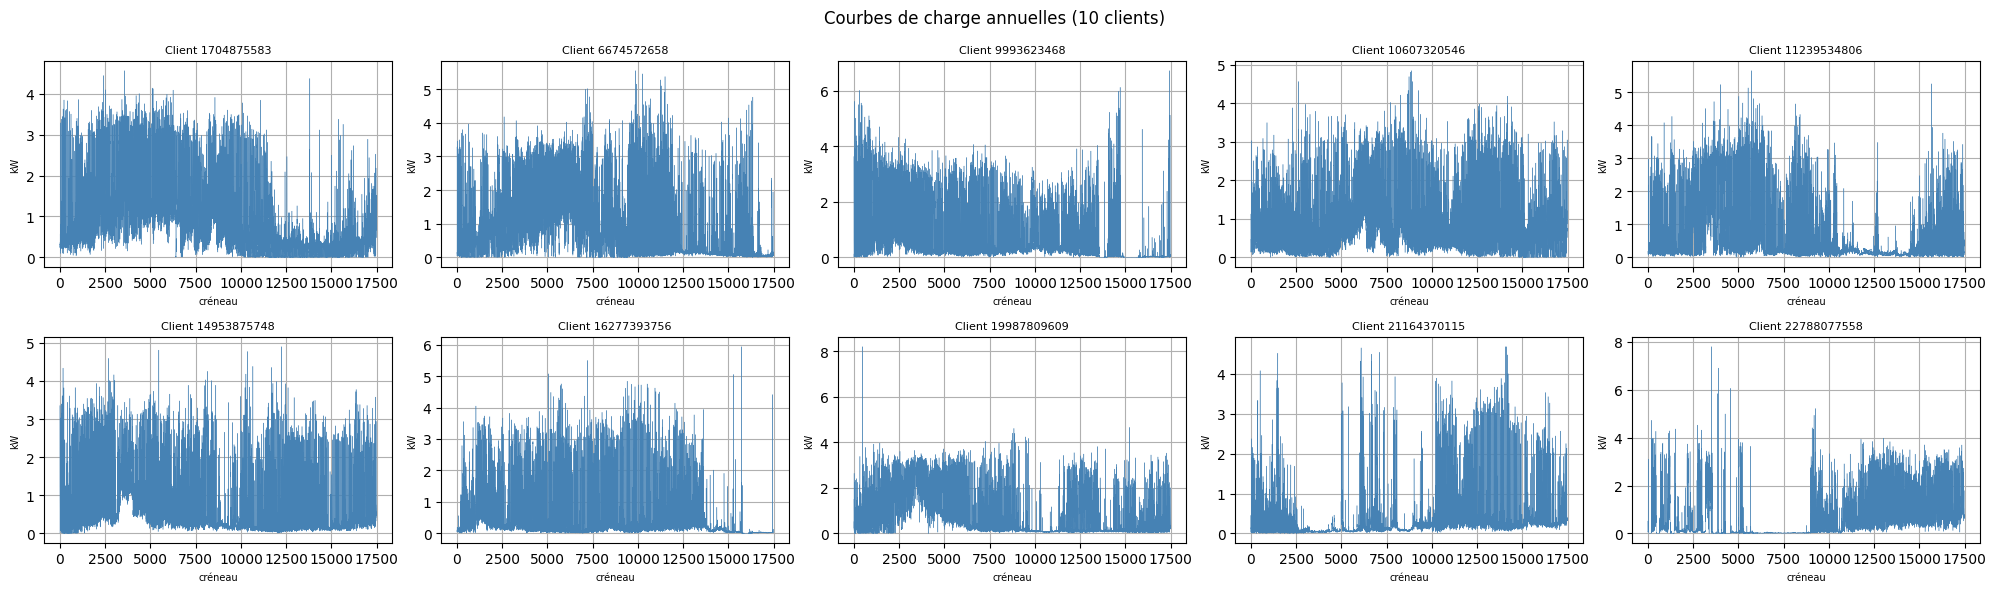

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
sample_ids = df_pivot.index[:10]

for ax, cid in zip(axes.flat, sample_ids):
    serie = df_pivot.loc[cid]
    ax.plot(serie.values, linewidth=0.3, color='steelblue')
    ax.set_title(f'Client {cid}', fontsize=8)
    ax.set_xlabel('créneau', fontsize=7)
    ax.set_ylabel('kW', fontsize=7)

plt.suptitle('Courbes de charge annuelles (10 clients)', fontsize=12)
plt.tight_layout()
plt.show()

## 1.5 Profil journalier moyen (heure de la journée)

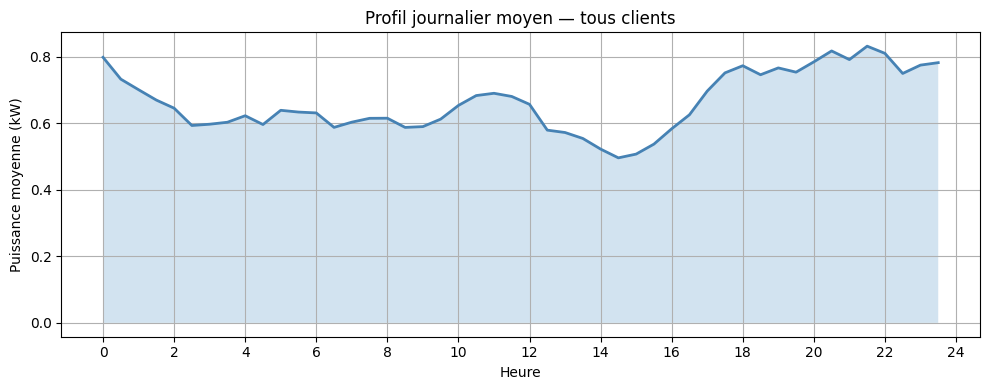

In [6]:
df['hour'] = df['horodate'].dt.hour + df['horodate'].dt.minute / 60
hourly_mean = df.groupby('hour')['kw'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_mean.index, hourly_mean.values, color='steelblue', linewidth=2)
ax.fill_between(hourly_mean.index, hourly_mean.values, alpha=0.2)
ax.set_xlabel('Heure')
ax.set_ylabel('Puissance moyenne (kW)')
ax.set_title('Profil journalier moyen — tous clients')
ax.set_xticks(range(0, 25, 2))
plt.tight_layout()
plt.show()

## 1.6 Distribution de la consommation totale par client

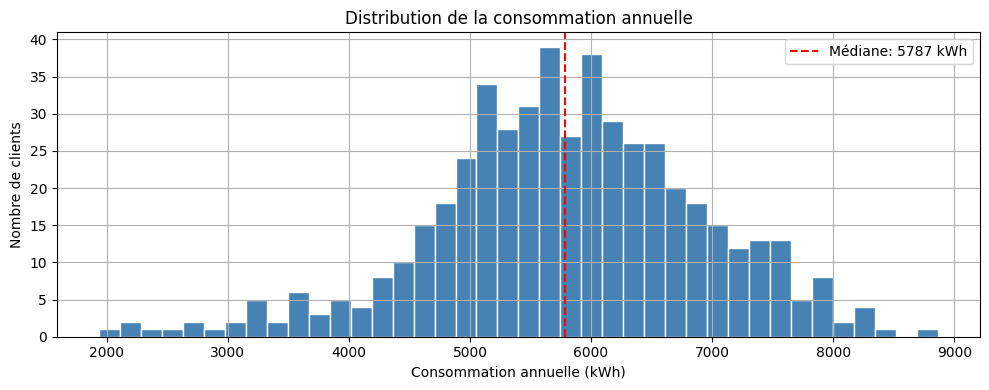

count     500.0
mean     5797.6
std      1128.4
min      1934.7
25%      5123.9
50%      5787.1
75%      6528.8
max      8866.6
dtype: float64


In [7]:
# kWh total par client (somme × 0.5 car pas = 30 min)
conso_totale = df_pivot.sum(axis=1) * 0.5

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(conso_totale, bins=40, color='steelblue', edgecolor='white')
ax.axvline(conso_totale.median(), color='red', linestyle='--', label=f'Médiane: {conso_totale.median():.0f} kWh')
ax.set_xlabel('Consommation annuelle (kWh)')
ax.set_ylabel('Nombre de clients')
ax.set_title('Distribution de la consommation annuelle')
ax.legend()
plt.tight_layout()
plt.show()

print(conso_totale.describe().round(1))

## 1.7 Saisonnalité : consommation mensuelle moyenne

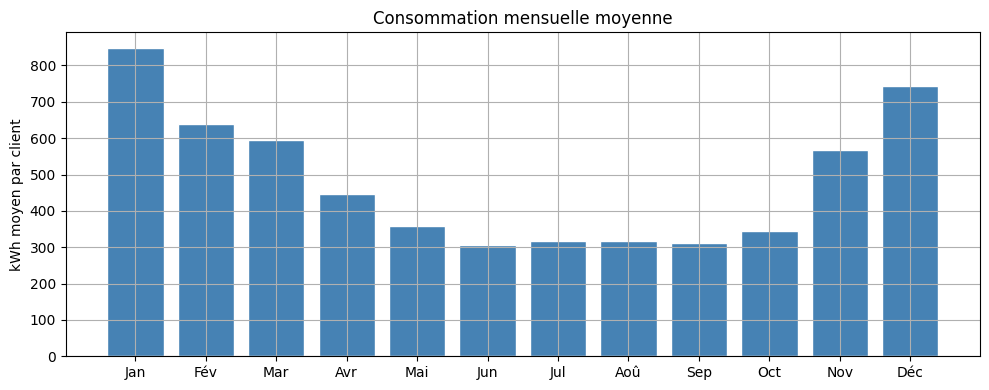

In [8]:
df['month'] = df['horodate'].dt.month
monthly = df.groupby(['ID', 'month'])['kw'].sum() * 0.5  # kWh
monthly_mean = monthly.groupby('month').mean()

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 13), [monthly_mean.get(m, 0) for m in range(1, 13)], color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_ylabel('kWh moyen par client')
ax.set_title('Consommation mensuelle moyenne')
plt.tight_layout()
plt.show()

## 1.8 Sauvegarde du pivot pour les notebooks suivants

In [9]:
df_pivot.to_parquet('../data/pivot.parquet')
df.to_parquet('../data/df_clean.parquet')
print("Sauvegardé : data/pivot.parquet et data/df_clean.parquet")

Sauvegardé : data/pivot.parquet et data/df_clean.parquet
